In [1]:
# load GT .npy files
import numpy as np
import os
import glob
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('--gt_dir', type=str, help='Directory containing GT .npy files')

def load_gt_npy_files(gt_dir):
    gt_files = glob.glob(os.path.join(gt_dir, '*.npy'))
    gt_data = {}
    for gt_file in gt_files:
        gt_name = os.path.basename(gt_file).split('.')[0]
        gt_data[gt_name] = np.load(gt_file)
    return gt_data

In [34]:
gt = load_gt_npy_files('GT_ref/')
print(gt.keys()) # Print the keys of the loaded GT data to verify)
# print(gt.get('101_label4')) # Print the GT data for '101_label0' to verify)
print(getattr(gt.get('101_label4'), 'shape')) # Print the shape of the GT data for '101_label0' to verify)
print(getattr(gt.get('101_label4'), 'dtype')) # Print the data type of the GT data for '101_label0' to verify)
for key, value in gt.items():
    print(f"{key}: shape={value.shape}, dtype={value.dtype}, ndim={value.ndim}, size={value.size}, itemsize={value.itemsize}, nbytes={value.nbytes}")

dict_keys(['101_label4', '101_label11', '101_label10', '101_label8', '101_label3', '101_label6', '101_label5', '101_label1', '101_label7', '101_label0', '101_label9', '101_label2'])
(160,)
float64
101_label4: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label11: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label10: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label8: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label3: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label6: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label5: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label1: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label7: shape=(160,), dtype=float64, ndim=1, size=160, itemsize=8, nbytes=1280
101_label0: shape=(160,), dtype=float64, ndim=1, size=

In [35]:
gt1 = gt.get('101_label0')
# print(gt1)

In [37]:
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

# Examine gt1 properties
print(f"Shape: {gt1.shape}")
print(f"Data type: {gt1.dtype}")
print(f"Min value: {gt1.min()}")
print(f"Max value: {gt1.max()}")
print(f"Mean: {gt1.mean()}")
print(f"Std: {gt1.std()}")
print(f"\nFirst 20 samples:\n{gt1[:20]}")

Shape: (160,)
Data type: float64
Min value: -0.969587654474601
Max value: 2.205239755778845
Mean: 0.31295564772908147
Std: 0.8420512471166492

First 20 samples:
[ 0.5466764   0.61260092  0.61260092  0.54989937  0.35749743  0.09594799
 -0.04019836 -0.23689761 -0.43359686 -0.49844706 -0.56329725 -0.69407198
 -0.77181408 -0.83773861 -0.78685464 -0.39091683  0.40916272  1.40769951
  2.07085139  2.1947895 ]


Text(0, 0.5, 'Amplitude')

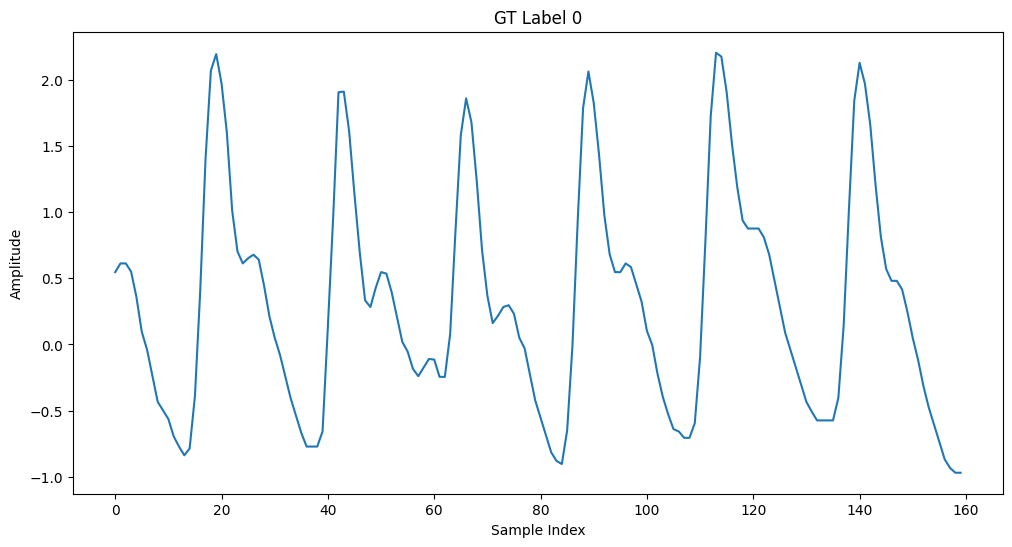

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(gt1)
plt.title('GT Label 0')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

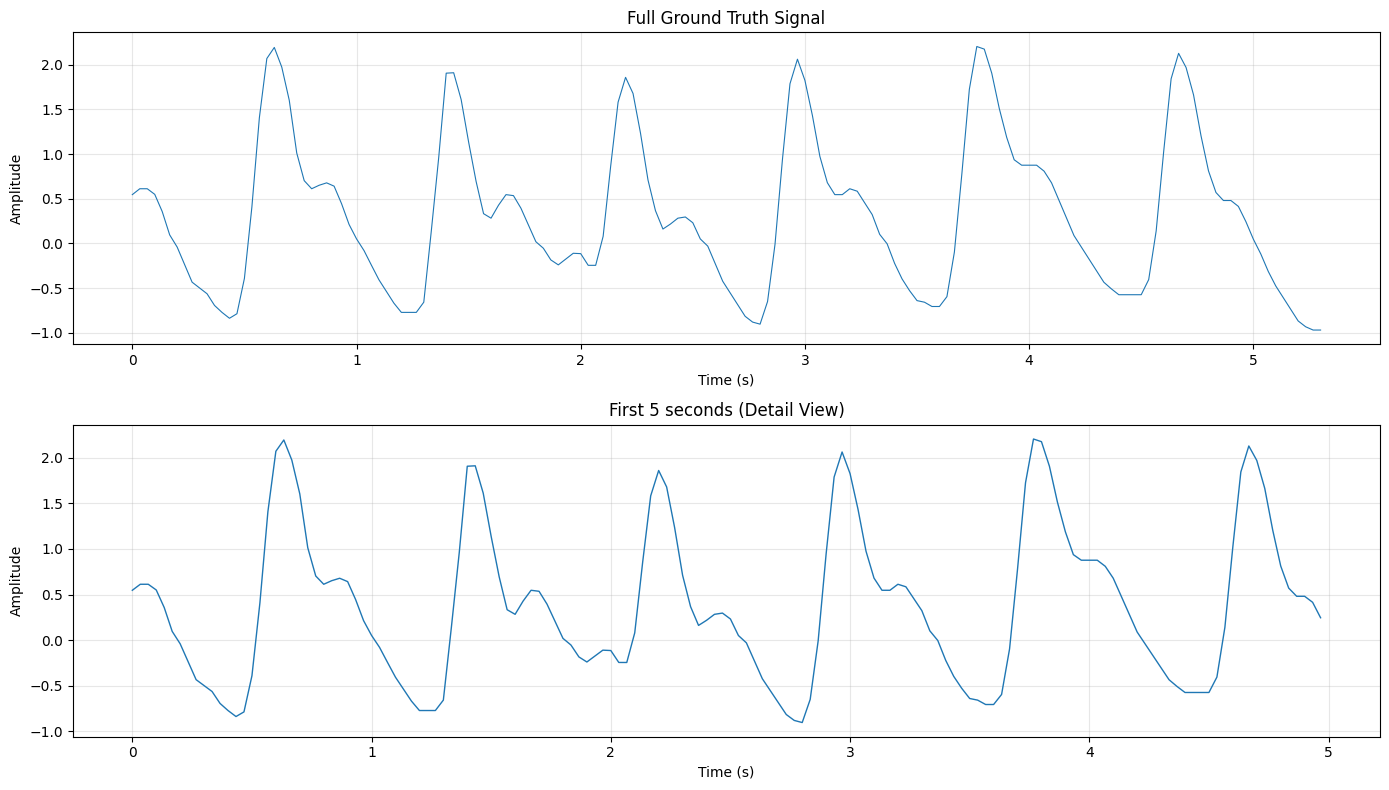

Total duration: 5.33 seconds (160 frames at 30 fps)


In [43]:
# Plot the signal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time axis (assuming 30 fps which is common for rPPG datasets)
fps = 30
time = np.arange(len(gt1)) / fps

# Plot 1: Full signal
axes[0].plot(time, gt1, linewidth=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Full Ground Truth Signal')
axes[0].grid(True, alpha=0.3)

# Plot 2: First 5 seconds for detail
if len(gt1) > fps * 5:
    axes[1].plot(time[:fps*5], gt1[:fps*5], linewidth=1)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')
    axes[1].set_title('First 5 seconds (Detail View)')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total duration: {len(gt1)/fps:.2f} seconds ({len(gt1)} frames at {fps} fps)")

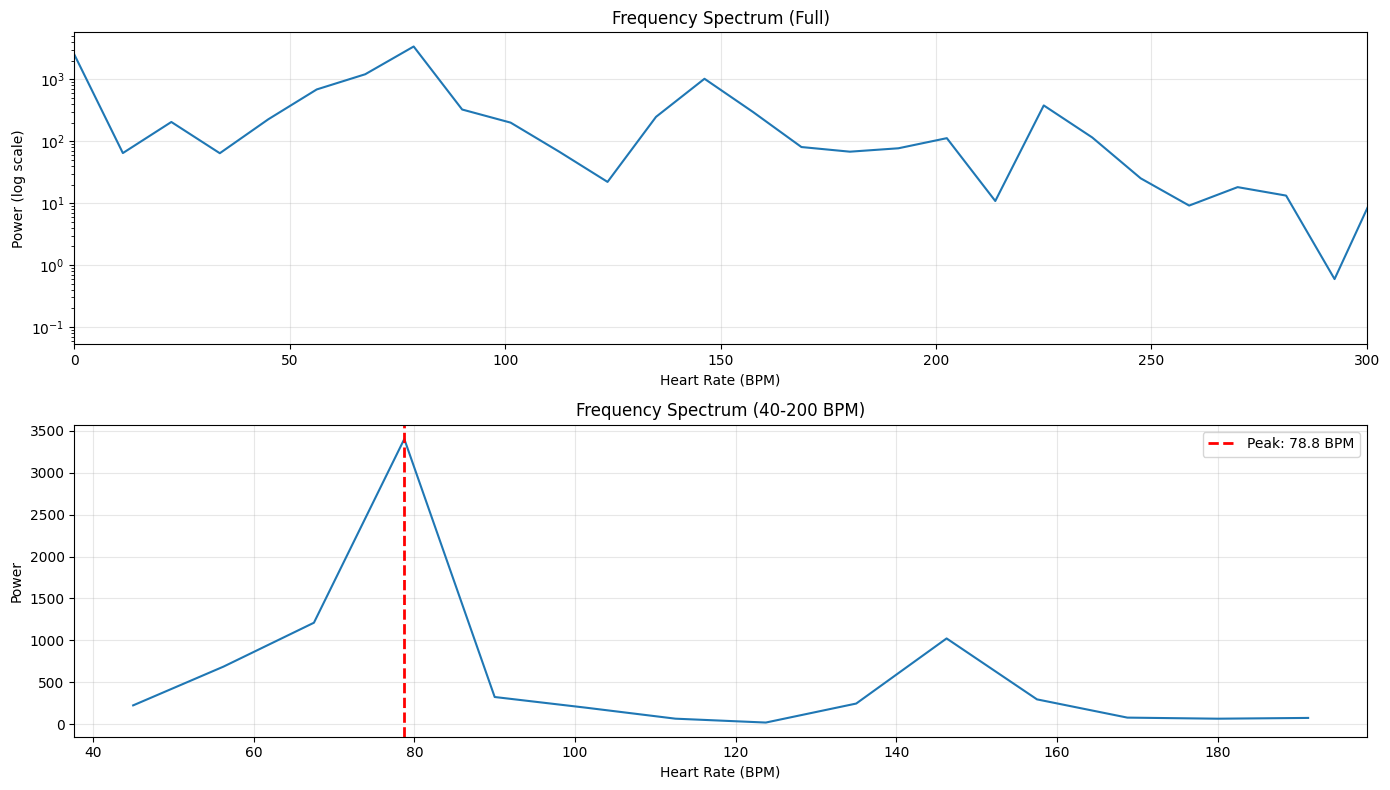

Dominant Heart Rate: 78.8 BPM


In [39]:
# Frequency domain analysis
fps = 30

# Compute FFT
fft = np.fft.fft(gt1)
freqs = np.fft.fftfreq(len(gt1), 1/fps)
power = np.abs(fft)**2

# Only positive frequencies
positive_freqs = freqs[:len(freqs)//2]
positive_power = power[:len(power)//2]

# Convert Hz to BPM (heart rate)
bpm_range = positive_freqs * 60

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Full frequency spectrum
axes[0].semilogy(bpm_range, positive_power)
axes[0].set_xlabel('Heart Rate (BPM)')
axes[0].set_ylabel('Power (log scale)')
axes[0].set_title('Frequency Spectrum (Full)')
axes[0].set_xlim([0, 300])  # Typical HR range
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoomed to typical HR range (40-200 BPM)
hr_mask = (bpm_range >= 40) & (bpm_range <= 200)
axes[1].plot(bpm_range[hr_mask], positive_power[hr_mask], linewidth=1.5)
axes[1].set_xlabel('Heart Rate (BPM)')
axes[1].set_ylabel('Power')
axes[1].set_title('Frequency Spectrum (40-200 BPM)')
axes[1].grid(True, alpha=0.3)

# Find dominant frequency
dominant_idx = np.argmax(positive_power[hr_mask])
dominant_bpm = bpm_range[hr_mask][dominant_idx]
axes[1].axvline(dominant_bpm, color='r', linestyle='--', linewidth=2, label=f'Peak: {dominant_bpm:.1f} BPM')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Dominant Heart Rate: {dominant_bpm:.1f} BPM")

In [58]:
# Peak detection
from scipy.signal import find_peaks

fps = 30

# Find peaks using multiple methods and compare
# Method 1: Using prominence (robustness to noise)
peaks_prom, properties_prom = find_peaks(gt1, prominence=0.3, distance=int(fps*0.3))

# Method 2: Using height threshold
peaks_height, properties_height = find_peaks(gt1, height=0.5)

# Method 3: Using standard deviation approach
threshold = gt1.mean() + gt1.std()
peaks_std, properties_std = find_peaks(gt1, height=threshold)

print(f"Peaks detected (prominence method): {len(peaks_prom)}")
print(f"Peaks detected (height method): {len(peaks_height)}")
print(f"Peaks detected (std method): {len(peaks_std)}")
print(f"\nPeak locations (prominence): {peaks_prom}")
print(f"Peak values: {gt1[peaks_prom]}")

# Calculate heart rate from peaks
if len(peaks_prom) > 1:
    # Calculate intervals between peaks in seconds
    peak_intervals = np.diff(peaks_prom) / fps
    # Convert to BPM
    heart_rates = 60 / peak_intervals
    print(f"\nHeart rates: {heart_rates}")
    print(f"\nHeart rate from peaks: {heart_rates.mean():.1f} ± {heart_rates.std():.1f} BPM")
    print(f"Min-Max HR: {heart_rates.min():.1f} - {heart_rates.max():.1f} BPM")

Peaks detected (prominence method): 6
Peaks detected (height method): 10
Peaks detected (std method): 6

Peak locations (prominence): [ 19  43  66  89 113 140]
Peak values: [2.1947895  1.91136288 1.86018591 2.06294045 2.20523976 2.12886497]

Heart rates: [75.         78.26086957 78.26086957 75.         66.66666667]

Heart rate from peaks: 74.6 ± 4.2 BPM
Min-Max HR: 66.7 - 78.3 BPM


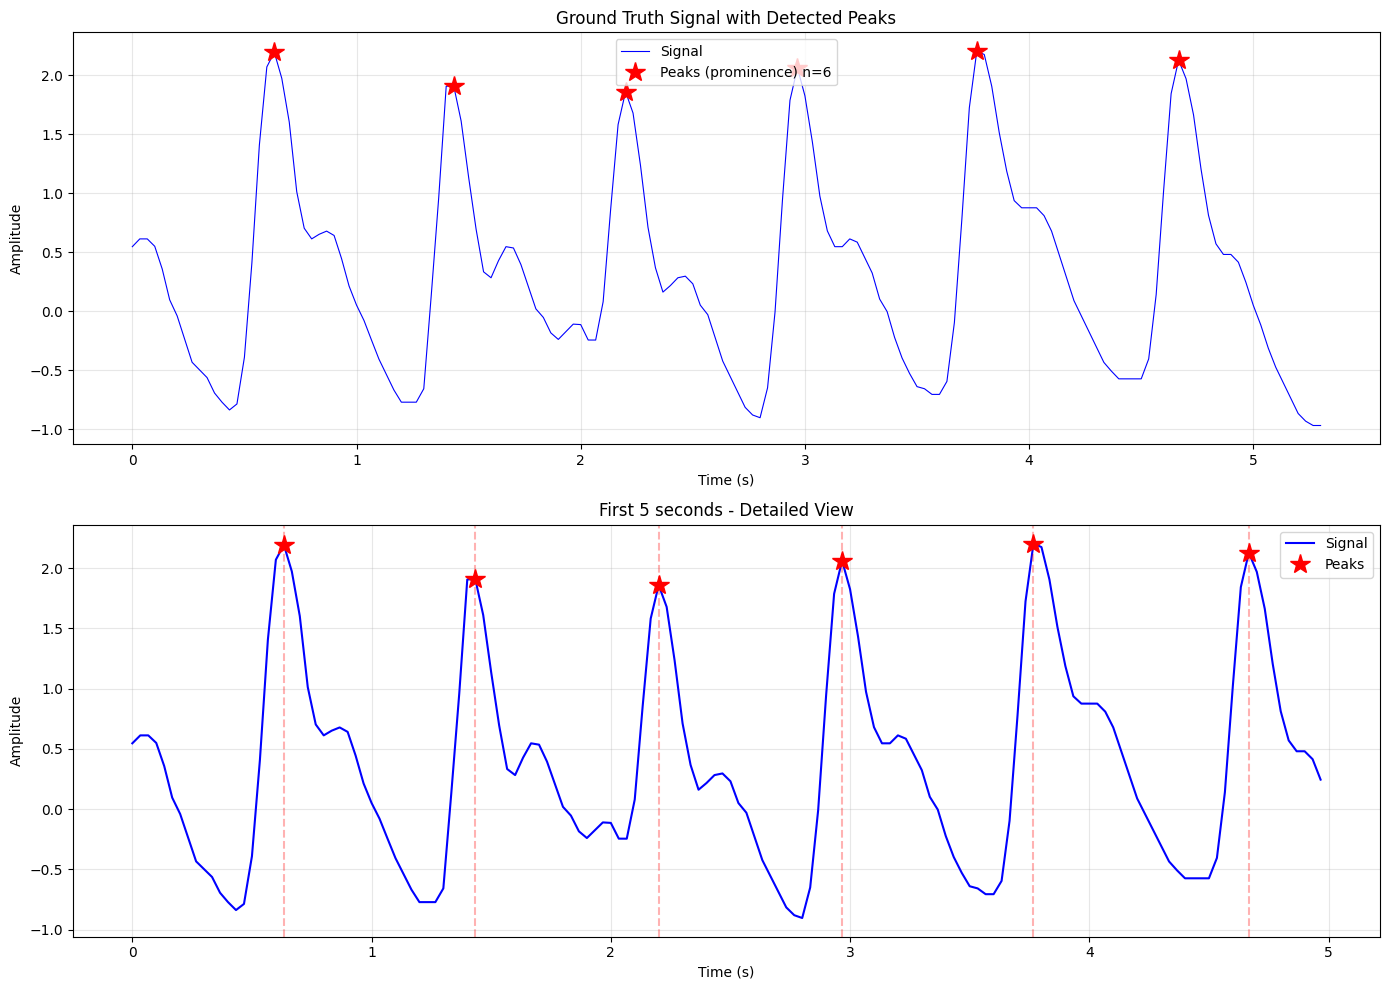

In [59]:
# Visualize detected peaks
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

fps = 30
time = np.arange(len(gt1)) / fps

# Plot 1: Full signal with all peaks
axes[0].plot(time, gt1, 'b-', linewidth=0.8, label='Signal')
axes[0].plot(time[peaks_prom], gt1[peaks_prom], 'r*', markersize=15, label=f'Peaks (prominence) n={len(peaks_prom)}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Ground Truth Signal with Detected Peaks')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: First 5 seconds with detail
if len(gt1) > fps * 5:
    axes[1].plot(time[:fps*5], gt1[:fps*5], 'b-', linewidth=1.5, label='Signal')
    # Filter peaks for this time window
    peaks_window = peaks_prom[peaks_prom < fps*5]
    axes[1].plot(time[peaks_window], gt1[peaks_window], 'r*', markersize=15, label='Peaks')
    # Add vertical lines at peaks for clarity
    for peak in peaks_window:
        axes[1].axvline(time[peak], color='r', alpha=0.3, linestyle='--')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')
    axes[1].set_title('First 5 seconds - Detailed View')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

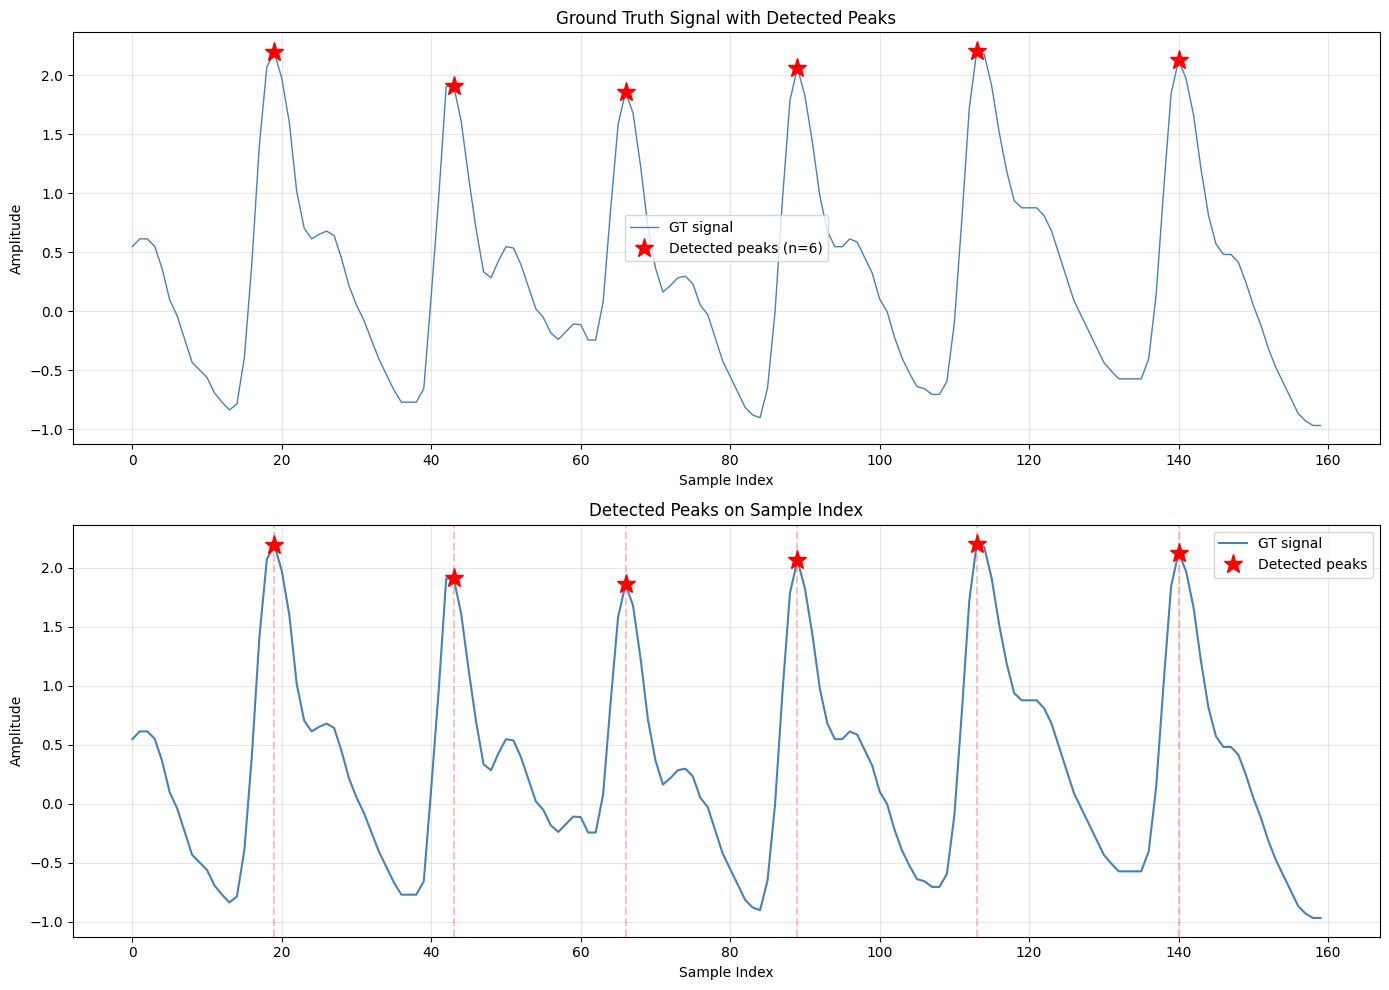

In [61]:
# Plot detected peaks on sample index in a separate cell
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sample_idx = np.arange(len(gt1))

# Full signal with all six detected peaks
axes[0].plot(sample_idx, gt1, color='steelblue', linewidth=1.0, label='GT signal')
axes[0].plot(peaks_prom, gt1[peaks_prom], 'r*', markersize=14, label=f'Detected peaks (n={len(peaks_prom)})')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Ground Truth Signal with Detected Peaks')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Zoomed view around the full sequence to make peak positions clearer
zoom_start = 0
zoom_end = len(gt1)
axes[1].plot(sample_idx[zoom_start:zoom_end], gt1[zoom_start:zoom_end], color='steelblue', linewidth=1.5, label='GT signal')
axes[1].plot(peaks_prom, gt1[peaks_prom], 'r*', markersize=14, label='Detected peaks')
for peak in peaks_prom:
    axes[1].axvline(peak, color='red', linestyle='--', alpha=0.25)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Detected Peaks on Sample Index')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [62]:
import numpy as np

def sliding_window_hr(signal, peaks, fps, window_size_sec=3, stride_sec=1):
    window_size = int(window_size_sec * fps)
    stride = int(stride_sec * fps)

    hr_values = []
    time_stamps = []

    for start in range(0, len(signal) - window_size + 1, stride):
        end = start + window_size

        # Step 1: select peaks in this window
        window_peaks = peaks[(peaks >= start) & (peaks < end)]

        # Step 2: need at least 2 peaks
        if len(window_peaks) < 2:
            continue

        # Step 3: compute inter-beat intervals
        intervals = np.diff(window_peaks) / fps

        # Step 4: convert to HR
        hr = 60 / intervals

        # Step 5: aggregate (robust choice = median)
        hr_values.append(np.median(hr))

        # timestamp = center of window (in seconds)
        time_stamps.append((start + window_size / 2) / fps)

    return time_stamps, hr_values

In [79]:
time_stamps, hr_values = sliding_window_hr(gt1, peaks_prom, fps=30, window_size_sec=4, stride_sec=0.3)
print(f"Time stamps: {time_stamps}")
print(f"Heart rate values: {hr_values}")

Time stamps: [2.0, 2.3, 2.6, 2.9, 3.2]
Heart rate values: [76.63043478260869, 76.63043478260869, 76.63043478260869, 76.63043478260869, 76.63043478260869]


In [33]:
gt = np.load('./GT_ref/101_label0.npy')
# print(gt)